# Haplotype analysis *Cyp9k1*

### Color palettes

In [1]:
# define dictionary of pop colors
pop_colours = {
 'East' : "lightgreen",
 'West' : "darkgreen",
}

dup_colours = {
    'Dup8 present' : 'blue',
    'Dup8 absent' : 'lightgray',
    'Dup16 present' : 'red',
    'Dup16 absent' : 'lightgray',
}


### Import packages

In [2]:
import malariagen_data
import allel
import numpy as np
import pandas as pd
import re
import scipy.cluster
from scipy.stats import spearmanr
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns



In [3]:
sample_sets = ["1288-VO-UG-DONNELLY-VMF00168","1288-VO-UG-DONNELLY-VMF00219"]
sample_query = "aim_species == 'gambiae' & sex_call == 'F'"
#load malariagen data
ag3 = malariagen_data.Ag3(pre = True)

In [6]:
fig = ag3.plot_diplotype_clustering_advanced(region ='X:15240000-15243900',
                                             #cnv_region='LOC125764726',
                                             cnv_region='AGAP000818',
                                             sample_query= sample_query,
                                             sample_sets=sample_sets,
                                             color='country',
                                             snp_transcript='AGAP000818-RA',
                                             show=True)
#'X:18,556,614-18,564,282',

Load sample metadata: ⠋ (0:00:00.00)

Load genotypes for distance calculation:   0%|          | 0/50 [00:00<?, ?it/s]

Load genotypes for heterozygosity calculation:   0%|          | 0/50 [00:00<?, ?it/s]

Load CNV HMM data:   0%|          | 0/44 [00:00<?, ?it/s]

Compute modal gene copy number:   0%|          | 0/1 [00:00<?, ?it/s]

Load SNP genotypes:   0%|          | 0/50 [00:00<?, ?it/s]

Compute SNP effects:   0%|          | 0/6879 [00:00<?, ?it/s]

No SNPs were found below 0.05 allele frequency. Omitting SNP genotype plot.


### Load CNV data

In [3]:
#load malariagen data
ag3 = malariagen_data.Ag3(pre = True)
# Initially, we don't use a sample query
meta = ag3.sample_metadata(
    sample_sets=sample_sets, 
)
# Remove decimal and numbers after it in the "partner_sample_id" column not present in our meta data
meta['partner_sample_id'] = meta['partner_sample_id'].str.split('.').str[0]
print(meta.shape)

# Convert "partner_sample_id" column in meta to float64 to match llineup_meta dtype
meta['partner_sample_id'] = pd.to_numeric(meta['partner_sample_id'])
#llineup trial metadata
llineup_meta = pd.read_csv('~/lstm_scratch/network_scratch/llineup/llineup-genomics/data/ento_geno_plasmo_data.csv',
                       index_col = 0,
                      ).query("species=='An. gambiae'")
llineup_meta= llineup_meta.drop_duplicates(subset=['wgs.sample.id'])
llineup_meta= llineup_meta.set_index('wgs.sample.id')
llineup_meta = llineup_meta.reindex(index=meta['partner_sample_id'])#match order in malariagen meta data
llineup_meta=llineup_meta.reset_index()
llineup_meta['sample_id'] =meta['sample_id'] #create sample id to merge with ag3 metadata
sample_query_filter = (meta['aim_species'] == 'gambiae') & (meta['sex_call'] == 'F')

#add column control phase for grouping samples to pre and post interventions
def recode_rnd(rnd):
    if rnd == 1:
        return 'pre'
    elif rnd == 5:
        return 'post'
    else:
        return 'intermediate'

llineup_meta['control_phase'] = llineup_meta['RND'].apply(recode_rnd)
llineup_meta.rename(columns={'LLIN.actual':'llin_actual'}, inplace = True)
ag3.add_extra_metadata(llineup_meta)
# Re-download the metadata with the additional columns
meta = ag3.sample_metadata(
    sample_sets=sample_sets, 
).set_index('sample_id')
meta['partner_sample_id'] = meta['partner_sample_id_x'].str.split('.').str[0]
meta['partner_sample_id'] = pd.to_numeric(meta['partner_sample_id'])

sample_query_filter = ((meta['aim_species'] == 'gambiae') & \
                      (meta['sex_call'] == 'F') & \
                      (np.array(list(meta['Location'])) != 'nan')).values
meta = meta.iloc[sample_query_filter, :]
meta


(1222, 57)                           


,partner_sample_id_x,contributor,country,location,year,month,latitude,longitude,sex_call,sample_set,...,LLIN.intend,llin_actual,Net.intend,Net.actual,Wave,Location,subregions,species,control_phase,partner_sample_id
sample_id,,,,,,,,,,,,,,,,,,,,,
VBS50275-6645STDY11194051,108402032009,Martin Donnelly,Uganda,8402,2017,5,0.878,33.333,F,1288-VO-UG-DONNELLY-VMF00168,...,Non-PBO LLIN,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,East,East Central,An. gambiae,pre,108402032009
VBS50276-6645STDY11194052,108402032004,Martin Donnelly,Uganda,8402,2017,5,0.878,33.333,F,1288-VO-UG-DONNELLY-VMF00168,...,Non-PBO LLIN,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,East,East Central,An. gambiae,pre,108402032004
VBS50283-6645STDY11194053,108405057028,Martin Donnelly,Uganda,8405,2017,5,0.957,33.341,F,1288-VO-UG-DONNELLY-VMF00168,...,Non-PBO LLIN,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,East,East Central,An. gambiae,pre,108405057028
VBS50286-6645STDY11194055,108405057024,Martin Donnelly,Uganda,8405,2017,5,0.957,33.341,F,1288-VO-UG-DONNELLY-VMF00168,...,Non-PBO LLIN,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,East,East Central,An. gambiae,pre,108405057024
VBS50287-6645STDY11194056,108405057036,Martin Donnelly,Uganda,8405,2017,5,0.957,33.341,F,1288-VO-UG-DONNELLY-VMF00168,...,Non-PBO LLIN,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,East,East Central,An. gambiae,pre,108405057036
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VBS67021-6645STDY13057665,400306001035.000,Martin Donnelly,Uganda,306,2019,9,0.713,29.996,F,1288-VO-UG-DONNELLY-VMF00219,...,Non-PBO LLIN,Non-PBO LLIN,Olyset,Olyset,5.0,West,Mid-Western,An. gambiae,intermediate,400306001035
VBS67022-6645STDY13057666,400306001036.000,Martin Donnelly,Uganda,306,2019,9,0.713,29.996,F,1288-VO-UG-DONNELLY-VMF00219,...,Non-PBO LLIN,Non-PBO LLIN,Olyset,Olyset,5.0,West,Mid-Western,An. gambiae,intermediate,400306001036
VBS67024-6645STDY13057668,400306001038.000,Martin Donnelly,Uganda,306,2019,9,0.713,29.996,F,1288-VO-UG-DONNELLY-VMF00219,...,Non-PBO LLIN,Non-PBO LLIN,Olyset,Olyset,5.0,West,Mid-Western,An. gambiae,intermediate,400306001038


In [4]:
# Identify samples that have Cyp9k1_Dup8 
discordant_read_calls_dup8 = (
    ag3
    .cnv_discordant_read_calls(contig="X", 
                               sample_sets=sample_sets)
    .set_index(samples="sample_id", variants="variant_id")
    .sel(variants='Cyp9k1_Dup8')
    .sel(samples = meta.index)
)
discordant_read_calls_dup8
Dup8_calls = discordant_read_calls_dup8.call_genotype.values

discordant_read_calls_dup16 = (
    ag3
    .cnv_discordant_read_calls(contig="X", 
                               sample_sets=sample_sets)
    .set_index(samples="sample_id", variants="variant_id")
    .sel(variants='Cyp9k1_Dup16')
    .sel(samples = meta.index)
)
discordant_read_calls_dup16
Dup16_calls = discordant_read_calls_dup16.call_genotype.values

discordant_read_calls_dup9k1 = (
    ag3
    .cnv_discordant_read_calls(contig="X", 
                               sample_sets=sample_sets)
    .set_index(samples="sample_id", variants="variant_id")
    #.sel(variants='Cyp9k1_Dup16')
    .sel(samples = meta.index)
)
discordant_read_calls_dup9k1
Dup9k1_calls = discordant_read_calls_dup9k1.call_genotype.values



In [36]:
Dup9k1_calls

array([[1, 1, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int8)

In [5]:
# Get haplotype-level metadata
hap_meta = pd.DataFrame(np.repeat(meta.values, 2, axis = 0))
hap_meta.columns = meta.columns
hap_meta.index = [np.repeat(meta.index, 2)[i] + ['a', 'b'][i%2] for i in range(len(hap_meta))]

hap_meta


,partner_sample_id_x,contributor,country,location,year,month,latitude,longitude,sex_call,sample_set,...,LLIN.intend,llin_actual,Net.intend,Net.actual,Wave,Location,subregions,species,control_phase,partner_sample_id
VBS50275-6645STDY11194051a,108402032009,Martin Donnelly,Uganda,8402,2017,5,0.878,33.333,F,1288-VO-UG-DONNELLY-VMF00168,...,Non-PBO LLIN,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,East,East Central,An. gambiae,pre,108402032009
VBS50275-6645STDY11194051b,108402032009,Martin Donnelly,Uganda,8402,2017,5,0.878,33.333,F,1288-VO-UG-DONNELLY-VMF00168,...,Non-PBO LLIN,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,East,East Central,An. gambiae,pre,108402032009
VBS50276-6645STDY11194052a,108402032004,Martin Donnelly,Uganda,8402,2017,5,0.878,33.333,F,1288-VO-UG-DONNELLY-VMF00168,...,Non-PBO LLIN,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,East,East Central,An. gambiae,pre,108402032004
VBS50276-6645STDY11194052b,108402032004,Martin Donnelly,Uganda,8402,2017,5,0.878,33.333,F,1288-VO-UG-DONNELLY-VMF00168,...,Non-PBO LLIN,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,East,East Central,An. gambiae,pre,108402032004
VBS50283-6645STDY11194053a,108405057028,Martin Donnelly,Uganda,8405,2017,5,0.957,33.341,F,1288-VO-UG-DONNELLY-VMF00168,...,Non-PBO LLIN,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,East,East Central,An. gambiae,pre,108405057028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VBS67024-6645STDY13057668b,400306001038.000,Martin Donnelly,Uganda,306,2019,9,0.713,29.996,F,1288-VO-UG-DONNELLY-VMF00219,...,Non-PBO LLIN,Non-PBO LLIN,Olyset,Olyset,5.0,West,Mid-Western,An. gambiae,intermediate,400306001038
VBS67025-6645STDY13057669a,400306001039.000,Martin Donnelly,Uganda,306,2019,9,0.713,29.996,F,1288-VO-UG-DONNELLY-VMF00219,...,Non-PBO LLIN,Non-PBO LLIN,Olyset,Olyset,5.0,West,Mid-Western,An. gambiae,intermediate,400306001039
VBS67025-6645STDY13057669b,400306001039.000,Martin Donnelly,Uganda,306,2019,9,0.713,29.996,F,1288-VO-UG-DONNELLY-VMF00219,...,Non-PBO LLIN,Non-PBO LLIN,Olyset,Olyset,5.0,West,Mid-Western,An. gambiae,intermediate,400306001039
VBS67026-6645STDY13057670a,400306001040.000,Martin Donnelly,Uganda,306,2019,9,0.713,29.996,F,1288-VO-UG-DONNELLY-VMF00219,...,Non-PBO LLIN,Non-PBO LLIN,Olyset,Olyset,5.0,West,Mid-Western,An. gambiae,intermediate,400306001040


In [6]:
# Access per-gene modal copy number data for all genes 
gene_copy_number = (
    ag3.gene_cnv(region="X", 
                 sample_sets=sample_sets,
                 max_coverage_variance = None
)
    .set_index(genes="gene_id", samples="sample_id")
    .sel(samples = meta.index)
)



# Select data for genes of interest, excluding samples with poor quality HMM data
cyp9k1_gene_copy_number = (
    gene_copy_number["CN_mode"]
    .sel(genes='AGAP000818')
    .transpose()
    .to_pandas()
)

good_variance = ~gene_copy_number.sample_is_high_variance.values


cyp9k1_gene_copy_number

Load CNV HMM data:   0%|          | 0/88 [00:00<?, ?it/s]

Compute modal gene copy number:   0%|          | 0/1063 [00:00<?, ?it/s]

samples
VBS50275-6645STDY11194051    3
VBS50276-6645STDY11194052    3
VBS50283-6645STDY11194053    2
VBS50286-6645STDY11194055    4
VBS50287-6645STDY11194056    4
                            ..
VBS67021-6645STDY13057665    3
VBS67022-6645STDY13057666    2
VBS67024-6645STDY13057668    4
VBS67025-6645STDY13057669    3
VBS67026-6645STDY13057670    4
Length: 1009, dtype: int8

In [7]:


Dup8_copy_number = (cyp9k1_gene_copy_number[good_variance]-2) * Dup8_calls[good_variance]
Dup16_copy_number = (cyp9k1_gene_copy_number[good_variance]-2) * Dup16_calls[good_variance]

meta_pbo= meta[meta['llin_actual'] == 'PBO LLIN']
meta_pre_pbo = meta_pbo[meta_pbo['control_phase'] == 'pre']
meta_post_pbo = meta_pbo[meta_pbo['control_phase']== 'post']
good_variance_pre = good_variance[meta.index.isin(meta_pre_pbo.index)]
good_variance_post = good_variance[meta.index.isin(meta_post_pbo.index)]



print("Pbo Pre-intervention samples")
display(pd.crosstab(meta_pre_pbo.loc[good_variance_pre, 'Location'], Dup8_copy_number))
print("Pbo Post-intervention samples")
display(pd.crosstab(meta_post_pbo.loc[good_variance_post, 'Location'], Dup8_copy_number))

meta_npbo= meta[meta['llin_actual'] == 'Non-PBO LLIN']
meta_pre_npbo = meta_npbo[meta_npbo['control_phase'] == 'pre']
meta_post_npbo = meta_npbo[meta_npbo['control_phase']== 'post']
good_variance_pre = good_variance[meta.index.isin(meta_pre_npbo.index)]
good_variance_post = good_variance[meta.index.isin(meta_post_npbo.index)]



print("Non Pbo Pre-intervention samples")
display(pd.crosstab(meta_pre_npbo.loc[good_variance_pre, 'Location'], Dup8_copy_number))
print("Non Pbo Post-intervention samples")
display(pd.crosstab(meta_post_npbo.loc[good_variance_post, 'Location'], Dup8_copy_number))



Pbo Pre-intervention samples


col_0,0,1,2,3
Location,,,,
East,51,35,19,2
West,11,24,36,1


Pbo Post-intervention samples


col_0,0,1,2,4
Location,,,,
East,21,16,1,1
West,3,5,6,0


Non Pbo Pre-intervention samples


col_0,0,1,2
Location,,,
East,80,39,11
West,20,29,26


Non Pbo Post-intervention samples


col_0,0,1,2
Location,,,
East,103,70,19
West,5,10,15


In [8]:
meta_pre = meta[meta['control_phase']== 'pre']
meta_pre

,partner_sample_id_x,contributor,country,location,year,month,latitude,longitude,sex_call,sample_set,...,LLIN.intend,llin_actual,Net.intend,Net.actual,Wave,Location,subregions,species,control_phase,partner_sample_id
sample_id,,,,,,,,,,,,,,,,,,,,,
VBS50275-6645STDY11194051,108402032009,Martin Donnelly,Uganda,8402,2017,5,0.878,33.333,F,1288-VO-UG-DONNELLY-VMF00168,...,Non-PBO LLIN,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,East,East Central,An. gambiae,pre,108402032009
VBS50276-6645STDY11194052,108402032004,Martin Donnelly,Uganda,8402,2017,5,0.878,33.333,F,1288-VO-UG-DONNELLY-VMF00168,...,Non-PBO LLIN,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,East,East Central,An. gambiae,pre,108402032004
VBS50283-6645STDY11194053,108405057028,Martin Donnelly,Uganda,8405,2017,5,0.957,33.341,F,1288-VO-UG-DONNELLY-VMF00168,...,Non-PBO LLIN,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,East,East Central,An. gambiae,pre,108405057028
VBS50286-6645STDY11194055,108405057024,Martin Donnelly,Uganda,8405,2017,5,0.957,33.341,F,1288-VO-UG-DONNELLY-VMF00168,...,Non-PBO LLIN,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,East,East Central,An. gambiae,pre,108405057024
VBS50287-6645STDY11194056,108405057036,Martin Donnelly,Uganda,8405,2017,5,0.957,33.341,F,1288-VO-UG-DONNELLY-VMF00168,...,Non-PBO LLIN,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,East,East Central,An. gambiae,pre,108405057036
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VBS64828-6645STDY13043532,102204042050.000,Martin Donnelly,Uganda,2204,2017,4,1.672,31.505,F,1288-VO-UG-DONNELLY-VMF00219,...,Non-PBO LLIN,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,West,Mid-Western,An. gambiae,pre,102204042050
VBS64838-6645STDY13043542,102204042049.000,Martin Donnelly,Uganda,2204,2017,4,1.672,31.505,F,1288-VO-UG-DONNELLY-VMF00219,...,Non-PBO LLIN,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,West,Mid-Western,An. gambiae,pre,102204042049
VBS65151-6645STDY13043884,105501023001.000,Martin Donnelly,Uganda,5501,2017,6,0.759,30.985,F,1288-VO-UG-DONNELLY-VMF00219,...,Non-PBO LLIN,Non-PBO LLIN,PermaNet-2,PermaNet-2,4.0,West,Mid-Western,An. gambiae,pre,105501023001


In [9]:
Dup16_copy_number = (cyp9k1_gene_copy_number[good_variance]-2) * Dup16_calls[good_variance]

display(pd.crosstab(meta.loc[good_variance, 'Location'], Dup16_copy_number))


col_0,0,1,2,3
Location,,,,
East,715,12,8,1
West,230,15,19,2


In [10]:
#Merge meta with dup 8 and 16 calls and copy  number for association with round.
meta_dup = meta[good_variance]
Dup8_calls_merge = discordant_read_calls_dup8.to_pandas()[['call_genotype']].rename(columns={'call_genotype':'dup8_calls'})[good_variance]
Dup16_calls_merge= discordant_read_calls_dup16.to_pandas()[['call_genotype']].rename(columns={'call_genotype':'dup16_calls'})[good_variance]
Dup8_copy_number_merge = Dup8_copy_number.reset_index().rename(columns={0: 'dup8_copy_number'}).set_index('samples')
Dup16_copy_number_merge = Dup16_copy_number.reset_index().rename(columns={0: 'dup16_copy_number'}).set_index('samples')

meta_merge = pd.concat([meta_dup,Dup8_calls_merge,Dup16_calls_merge,Dup8_copy_number_merge,Dup16_copy_number_merge], axis = 1)
#meta_merge.to_csv('meta_dup_calls.csv', index=False)


In [11]:
meta_merge.columns

Index(['partner_sample_id_x', 'contributor', 'country', 'location', 'year',
       'month', 'latitude', 'longitude', 'sex_call', 'sample_set',
       ...
       'Wave', 'Location', 'subregions', 'species', 'control_phase',
       'partner_sample_id', 'dup8_calls', 'dup16_calls', 'dup8_copy_number',
       'dup16_copy_number'],
      dtype='object', length=101)

In [12]:
dups = meta_merge[['dup8_calls','dup16_calls','control_phase', 'Location', 'llin_actual', 'RND']]

In [16]:


# assume df is your DataFrame
freq = (
    dups
    .groupby(['Location', 'llin_actual', 'control_phase'])
    .agg(dup8_freq=('dup8_calls', 'mean'),
         n=('dup8_calls', 'size'))
    .reset_index()
)
freq

,Location,llin_actual,control_phase,dup8_freq,n
0,East,Non-PBO LLIN,intermediate,0.498054,257
1,East,Non-PBO LLIN,post,0.463542,192
2,East,Non-PBO LLIN,pre,0.384615,130
3,East,PBO LLIN,intermediate,0.454545,11
4,East,PBO LLIN,post,0.461538,39
5,East,PBO LLIN,pre,0.523364,107
6,West,Non-PBO LLIN,intermediate,0.914286,70
7,West,Non-PBO LLIN,post,0.833333,30
8,West,Non-PBO LLIN,pre,0.733333,75
9,West,PBO LLIN,intermediate,1.000000,5


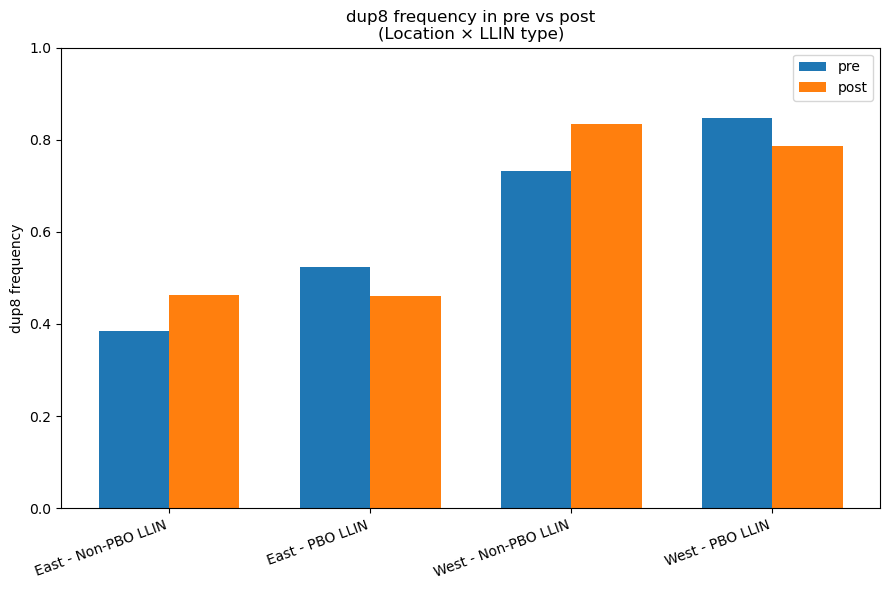

In [18]:

df2 = freq[freq['control_phase'].isin(['pre', 'post'])].copy()
# Create a combined grouping variable
df2['group'] = df2['Location'] + " - " + df2['llin_actual']

# Specify order
group_order = [
    "East - Non-PBO LLIN",
    "East - PBO LLIN",
    "West - Non-PBO LLIN",
    "West - PBO LLIN"
]

phase_order = ['pre', 'post']
df2['control_phase'] = pd.Categorical(df2['control_phase'], categories=phase_order, ordered=True)

# Pivot to wide format
pivot = (
    df2
    .pivot(index='group', columns='control_phase', values='dup8_freq')
    .reindex(group_order)
)

# --- Plot ---
fig, ax = plt.subplots(figsize=(9,6))

x = np.arange(len(group_order))
width = 0.35

ax.bar(x - width/2, pivot['pre'], width, label='pre')
ax.bar(x + width/2, pivot['post'], width, label='post')

ax.set_xticks(x)
ax.set_xticklabels(group_order, rotation=20, ha='right')

ax.set_ylabel("dup8 frequency")
ax.set_ylim(0, 1)
ax.set_title("dup8 frequency in pre vs post\n(Location × LLIN type)")

ax.legend()

plt.tight_layout()
plt.savefig("/home/harunnn/lstm_scratch/network_scratch/llineup/llineup-genomics/Notebooks/dup8_folder/dup8_pre_post.svg", format="svg")
plt.show()

/tmp/ipykernel_3389863/4208832443.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


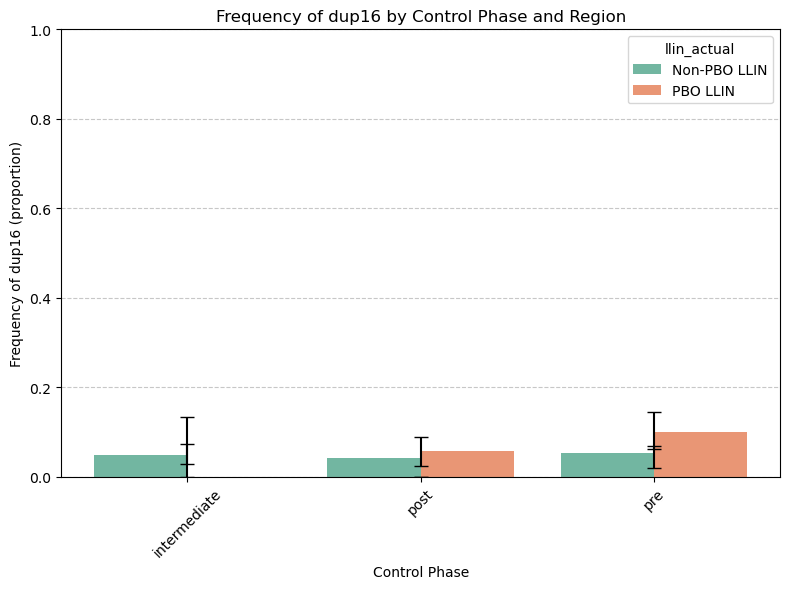

In [72]:

from scipy.stats import binom

df = dups.copy()
# Group and summarize
summary = (
    df.groupby(['control_phase', 'llin_actual'])['dup16_calls']
    .agg(['sum', 'count'])
    .reset_index()
)
summary.rename(columns={'sum': 'dup16_positive', 'count': 'total'}, inplace=True)
summary['frequency'] = summary['dup16_positive'] / summary['total']

# Compute 95% binomial confidence intervals
summary['ci_low'], summary['ci_high'] = binom.interval(
    0.95,
    summary['total'],
    summary['frequency']
)
summary['ci_low'] = summary['ci_low'] / summary['total']
summary['ci_high'] = summary['ci_high'] / summary['total']
summary['error'] = summary['ci_high'] - summary['frequency']  # for symmetrical-ish bars

# Plot with error bars
plt.figure(figsize=(8, 6))
sns.barplot(
    data=summary,
    x='control_phase',
    y='frequency',
    hue='llin_actual',
    dodge=True,
    palette='Set2',
    ci=None  # Turn off built-in CIs since we’re adding custom ones
)

# Add error bars manually
for i, row in summary.iterrows():
    plt.errorbar(
        x=i % len(summary['control_phase'].unique()),  # position within control_phase
        y=row['frequency'],
        yerr=[[row['frequency'] - row['ci_low']], [row['ci_high'] - row['frequency']]],
        fmt='none',
        c='black',
        capsize=5
    )

plt.title("Frequency of dup16 by Control Phase and Region")
plt.ylabel("Frequency of dup16 (proportion)")
plt.xlabel("Control Phase")
plt.ylim(0, 1)
plt.legend(title='llin_actual', loc='upper right')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


/home/harunnn/.conda/envs/gaard/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/harunnn/.conda/envs/gaard/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/harunnn/.conda/envs/gaard/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/harunnn/.conda/envs/gaard/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning:

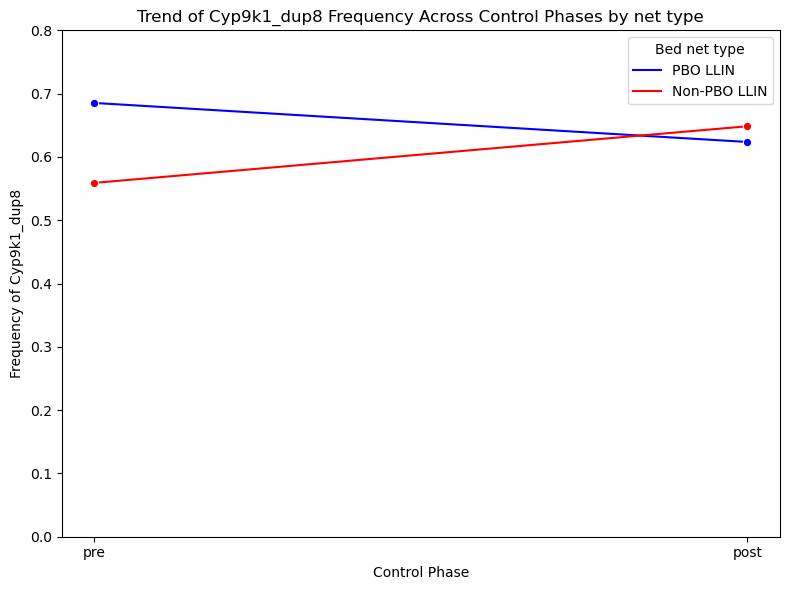

In [102]:


# Group and summarize
summary = (
    df.groupby(['control_phase', 'llin_actual', 'Location'])['dup8_calls']
    .agg(['sum', 'count'])
    .reset_index()
)
summary.rename(columns={'sum': 'dup8_positive', 'count': 'total'}, inplace=True)
summary['frequency'] = summary['dup8_positive'] / summary['total']

# Compute 95% binomial confidence intervals
summary['ci_low'], summary['ci_high'] = binom.interval(
    0.95,
    summary['total'],
    summary['frequency']
)
summary['ci_low'] = summary['ci_low'] / summary['total']
summary['ci_high'] = summary['ci_high'] / summary['total']

# Ensure control_phase is ordered
#phase_order = ['pre', 'intermediate', 'post']
phase_order = ['pre',  'post']
summary['control_phase'] = pd.Categorical(summary['control_phase'], categories=phase_order, ordered=True)

plt.figure(figsize=(8, 6))
sns.lineplot(
    data=summary,
    x='control_phase',
    y='frequency',
    hue='llin_actual',  # or 'llin_actual' if that's your new label
    marker='o',
    hue_order=['PBO LLIN', 'Non-PBO LLIN'],
    palette=['blue', 'red'],
    errorbar= None

)


plt.ylim(0, 0.8)

plt.title("Trend of Cyp9k1_dup8 Frequency Across Control Phases by net type")
plt.ylabel("Frequency of Cyp9k1_dup8")
plt.xlabel("Control Phase")
plt.legend(title='Bed net type')  # Adjust title if using LLIN type
plt.tight_layout()
plt.show()




/home/harunnn/.conda/envs/gaard/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/harunnn/.conda/envs/gaard/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/harunnn/.conda/envs/gaard/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/harunnn/.conda/envs/gaard/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning:

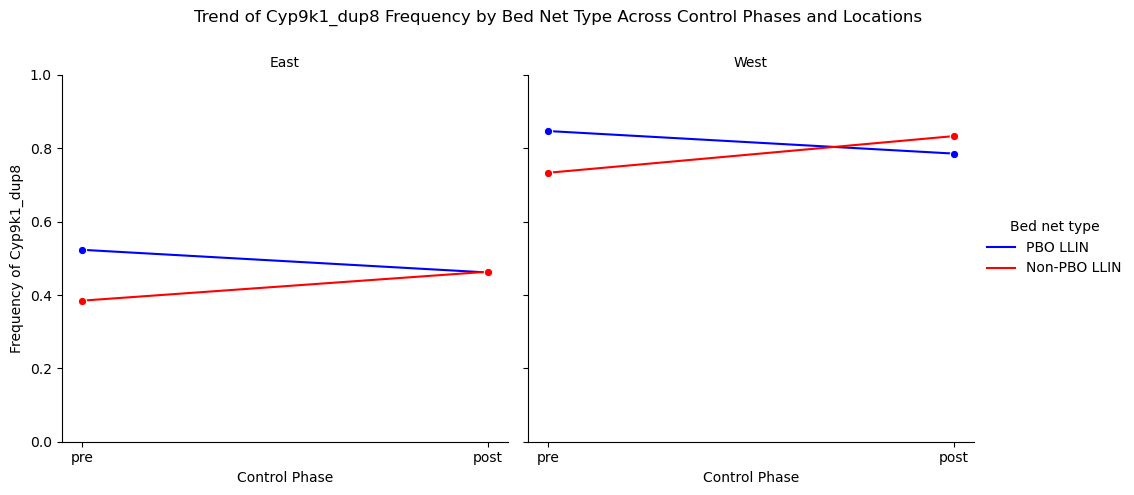

In [111]:
# Group and summarize
summary = (
    df.groupby(['control_phase', 'llin_actual', 'Location'])['dup8_calls']
    .agg(['sum', 'count'])
    .reset_index()
)
summary.rename(columns={'sum': 'dup8_positive', 'count': 'total'}, inplace=True)
summary['frequency'] = summary['dup8_positive'] / summary['total']

# Compute 95% binomial confidence intervals
summary['ci_low'], summary['ci_high'] = binom.interval(
    0.95,
    summary['total'],
    summary['frequency']
)
summary['ci_low'] = summary['ci_low'] / summary['total']
summary['ci_high'] = summary['ci_high'] / summary['total']

# Ensure control_phase is ordered
#phase_order = ['pre', 'intermediate', 'post']
phase_order = ['pre',  'post']
summary['control_phase'] = pd.Categorical(summary['control_phase'], categories=phase_order, ordered=True)
# Create the faceted line plot
g = sns.relplot(
    data=summary,
    x='control_phase',
    y='frequency',
    hue='llin_actual',
    col='Location',
    kind='line',
    marker='o',
    palette=['blue', 'red'],
    hue_order=['PBO LLIN', 'Non-PBO LLIN'],
    facet_kws={'sharey': True}
)

# Customize appearance
g.set_titles("{col_name}")
g.set_axis_labels("Control Phase", "Frequency of Cyp9k1_dup8")
g.set(ylim=(0, 1))
g._legend.set_title("Bed net type")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Trend of Cyp9k1_dup8 Frequency by Bed Net Type Across Control Phases and Locations")

# Save as SVG
g.savefig("dup8_frequency_location.svg", format="svg")

# Optional: Show the plot
plt.show()

/home/harunnn/.conda/envs/gaard/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/harunnn/.conda/envs/gaard/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/harunnn/.conda/envs/gaard/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/harunnn/.conda/envs/gaard/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning:

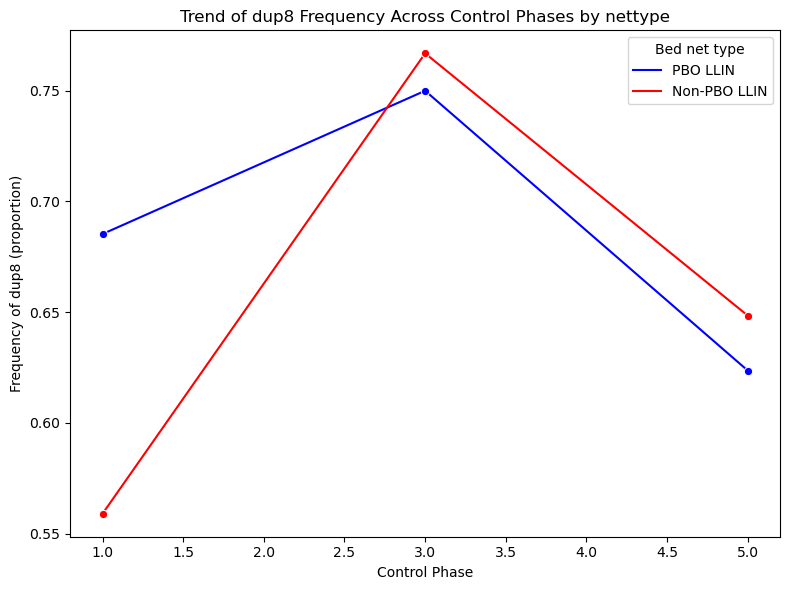

In [108]:

# Group and summarize
summary = (
    df.groupby(['RND', 'llin_actual', 'Location'])['dup8_calls']
    .agg(['sum', 'count'])
    .reset_index()
)
summary.rename(columns={'sum': 'dup8_positive', 'count': 'total'}, inplace=True)
summary['frequency'] = summary['dup8_positive'] / summary['total']

# Compute 95% binomial confidence intervals
summary['ci_low'], summary['ci_high'] = binom.interval(
    0.95,
    summary['total'],
    summary['frequency']
)
summary['ci_low'] = summary['ci_low'] / summary['total']
summary['ci_high'] = summary['ci_high'] / summary['total']

# Ensure control_phase is ordered
phase_order = [1,3,5]
summary['RND'] = pd.Categorical(summary['RND'], categories=phase_order, ordered=True)

plt.figure(figsize=(8, 6))
sns.lineplot(
    data=summary,
    x='RND',
    y='frequency',
    hue='llin_actual',  # or 'llin_actual' if that's your new label
    marker='o',
    hue_order=['PBO LLIN', 'Non-PBO LLIN'],
    palette=['blue', 'red'],
    errorbar= None
)


#plt.ylim(0, 1)

plt.title("Trend of dup8 Frequency Across Control Phases by nettype")
plt.ylabel("Frequency of dup8 (proportion)")
plt.xlabel("Control Phase")
plt.legend(title='Bed net type')  # Adjust title if using LLIN type
plt.tight_layout()
plt.show()




In [77]:
# Group and summarize
summary = (
    df.groupby(['RND', 'llin_actual', 'Location'])['dup16_calls']
    .agg(['sum', 'count'])
    .reset_index()
)

summary

,RND,llin_actual,Location,sum,count
0,1.0,Non-PBO LLIN,East,2,130
1,1.0,Non-PBO LLIN,West,9,75
2,1.0,PBO LLIN,East,4,107
3,1.0,PBO LLIN,West,14,72
4,2.0,Non-PBO LLIN,East,2,47
5,2.0,Non-PBO LLIN,West,0,3
6,2.0,PBO LLIN,West,0,1
7,3.0,Non-PBO LLIN,East,4,148
8,3.0,Non-PBO LLIN,West,1,6
9,3.0,PBO LLIN,East,0,10


### Load the haplotype data

In [42]:
region='X:15000000-15500000'

haps = (
    ag3.haplotypes(region = region, 
                   analysis = 'gamb_colu', 
                   sample_sets = sample_sets)
    .set_index(samples = 'sample_id')
    .sel(samples = meta.index)

)

haps_Dup = haps.isel(samples = good_variance)
haps_Dup

<xarray.Dataset> Size: 250MB
Dimensions:           (variants: 124185, alleles: 2, samples: 1002, ploidy: 2)
Coordinates:
    variant_position  (variants) int32 497kB dask.array<chunksize=(124185,), meta=np.ndarray>
    variant_contig    (variants) uint8 124kB dask.array<chunksize=(124185,), meta=np.ndarray>
  * samples           (samples) object 8kB 'VBS50275-6645STDY11194051' ... 'V...
Dimensions without coordinates: variants, alleles, ploidy
Data variables:
    variant_allele    (variants, alleles) |S1 248kB dask.array<chunksize=(124185, 1), meta=np.ndarray>
    call_genotype     (variants, samples, ploidy) int8 249MB dask.array<chunksize=(124185, 64, 2), meta=np.ndarray>
Attributes:
    contigs:   ('2R', '2L', '3R', '3L', 'X')
    analysis:  gamb_colu

In [43]:
# Create haplotype array
hap_array_Dup = allel.GenotypeArray(haps_Dup.call_genotype).to_haplotypes()

# Get allele counts
ac = hap_array_Dup.count_alleles()

# Identify segregating non-singletons. 
non_singleton = ac.min(1) > 1

# Filter the datasets, removing non-segregating and singleton variants 
haps_Dup = haps_Dup.isel(variants = np.where(non_singleton)[0])
hap_array_Dup = hap_array_Dup[non_singleton]


In [44]:
# Get the SNP genotypes coded as 0, 1, 2 (wt, het, homozygote mutant). Since all phased SNPs
# are biallelic, this is a suitable way to code genotype. 
genotypes = haps_Dup.call_genotype.values.sum(2)
genotypes

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [2, 2, 2, ..., 2, 2, 2],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [45]:
meta.shape

(1009, 97)

In [46]:
Dup8_calls.shape

(1009,)

In [47]:
discordant_read_calls_dup8.to_pandas()['call_genotype']

samples
VBS50275-6645STDY11194051    1
VBS50276-6645STDY11194052    1
VBS50283-6645STDY11194053    0
VBS50286-6645STDY11194055    1
VBS50287-6645STDY11194056    1
                            ..
VBS67021-6645STDY13057665    1
VBS67022-6645STDY13057666    0
VBS67024-6645STDY13057668    1
VBS67025-6645STDY13057669    1
VBS67026-6645STDY13057670    1
Name: call_genotype, Length: 1009, dtype: int8

In [48]:
np.all(meta.index == discordant_read_calls_dup8.samples.values)

True

In [49]:
meta['Dup8'] = discordant_read_calls_dup8.call_genotype
meta

,partner_sample_id_x,contributor,country,location,year,month,latitude,longitude,sex_call,sample_set,...,llin_actual,Net.intend,Net.actual,Wave,Location,subregions,species,control_phase,partner_sample_id,Dup8
sample_id,,,,,,,,,,,,,,,,,,,,,
VBS50275-6645STDY11194051,108402032009,Martin Donnelly,Uganda,8402,2017,5,0.878,33.333,F,1288-VO-UG-DONNELLY-VMF00168,...,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,East,East Central,An. gambiae,pre,108402032009,1
VBS50276-6645STDY11194052,108402032004,Martin Donnelly,Uganda,8402,2017,5,0.878,33.333,F,1288-VO-UG-DONNELLY-VMF00168,...,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,East,East Central,An. gambiae,pre,108402032004,1
VBS50283-6645STDY11194053,108405057028,Martin Donnelly,Uganda,8405,2017,5,0.957,33.341,F,1288-VO-UG-DONNELLY-VMF00168,...,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,East,East Central,An. gambiae,pre,108405057028,0
VBS50286-6645STDY11194055,108405057024,Martin Donnelly,Uganda,8405,2017,5,0.957,33.341,F,1288-VO-UG-DONNELLY-VMF00168,...,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,East,East Central,An. gambiae,pre,108405057024,1
VBS50287-6645STDY11194056,108405057036,Martin Donnelly,Uganda,8405,2017,5,0.957,33.341,F,1288-VO-UG-DONNELLY-VMF00168,...,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,East,East Central,An. gambiae,pre,108405057036,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VBS67021-6645STDY13057665,400306001035.000,Martin Donnelly,Uganda,306,2019,9,0.713,29.996,F,1288-VO-UG-DONNELLY-VMF00219,...,Non-PBO LLIN,Olyset,Olyset,5.0,West,Mid-Western,An. gambiae,intermediate,400306001035,1
VBS67022-6645STDY13057666,400306001036.000,Martin Donnelly,Uganda,306,2019,9,0.713,29.996,F,1288-VO-UG-DONNELLY-VMF00219,...,Non-PBO LLIN,Olyset,Olyset,5.0,West,Mid-Western,An. gambiae,intermediate,400306001036,0
VBS67024-6645STDY13057668,400306001038.000,Martin Donnelly,Uganda,306,2019,9,0.713,29.996,F,1288-VO-UG-DONNELLY-VMF00219,...,Non-PBO LLIN,Olyset,Olyset,5.0,West,Mid-Western,An. gambiae,intermediate,400306001038,1


### Identify proxy SNPs

In [50]:
# We look for SNPs whose presence / absence patterns are perfectly correlated with CNV presence. 
SNP_cor_dup8 = np.apply_along_axis(lambda x: spearmanr((x>0).astype('int'), 
                                                  Dup8_calls[good_variance]), 
                                    1, 
                                    genotypes)[:, 0]
SNP_cor_dup8 = np.abs(SNP_cor_dup8)
print(f'The maximum correlation coefficient with the Dup is {np.nanmax(SNP_cor_dup8)}')

/tmp/ipykernel_3389863/3170516293.py:2: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  SNP_cor_dup8 = np.apply_along_axis(lambda x: spearmanr((x>0).astype('int'),


The maximum correlation coefficient with the Dup is 0.9858131149957308


In [51]:
# We look for SNPs whose presence / absence patterns are perfectly correlated with CNV presence. 
SNP_cor_dup16 = np.apply_along_axis(lambda x: spearmanr((x>0).astype('int'), 
                                                  Dup16_calls[good_variance]), 
                                    1, 
                                    genotypes)[:, 0]
SNP_cor_dup16 = np.abs(SNP_cor_dup16)
print(f'The maximum correlation coefficient with the Dup is {np.nanmax(SNP_cor_dup16)}')

/tmp/ipykernel_3389863/2740316837.py:2: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  SNP_cor_dup16 = np.apply_along_axis(lambda x: spearmanr((x>0).astype('int'),


The maximum correlation coefficient with the Dup is 1.0


In [52]:
Dup8_proxy_SNP_position = haps_Dup.variant_position[np.nanargmax(SNP_cor_dup8)].values
Dup8_proxy = genotypes[np.nanargmax(SNP_cor_dup8)]


print(f'The Dup8 proxy SNP is at positions {Dup8_proxy_SNP_position}')
print('Association of Dup proxy zygosity and Dup copy number')
display(
    pd.crosstab(Dup8_copy_number,
                Dup8_proxy)
)

The Dup8 proxy SNP is at positions 15249607
Association of Dup proxy zygosity and Dup copy number


col_0,0,1,2
row_0,,,
0,429,6,0
1,1,358,3
2,0,42,157
3,0,3,2
4,0,1,0


In [53]:
Dup16_proxy_SNP_position = haps_Dup.variant_position[np.nanargmax(SNP_cor_dup16)].values
Dup16_proxy = genotypes[np.nanargmax(SNP_cor_dup16)]

# Let's look at the association of zygosity at those SNPs and copy number. 
print(f'The Dup16 proxy SNP is at positions {Dup16_proxy_SNP_position}')
print('Association of Dup proxy zygosity and Dup copy number')
display(
    pd.crosstab(Dup16_copy_number,
                Dup16_proxy)
)


The Dup16 proxy SNP is at positions 15239222
Association of Dup proxy zygosity and Dup copy number


col_0,0,1
row_0,,
0,945,0
1,0,27
2,0,27
3,0,3


It's an ok proxy

In [54]:
Dup8_hap_proxy = hap_array_Dup[np.nanargmax(SNP_cor_dup8)]
Dup8_hap_proxy

array([0, 1, 1, ..., 0, 1, 1], dtype=int8)

In [55]:
Dup16_hap_proxy = hap_array_Dup[np.nanargmax(SNP_cor_dup16)]
Dup16_hap_proxy

array([0, 0, 0, ..., 0, 0, 0], dtype=int8)

In [56]:
hap_meta_Dup = hap_meta.iloc[np.repeat(good_variance, 2), :]
hap_meta_Dup

,partner_sample_id_x,contributor,country,location,year,month,latitude,longitude,sex_call,sample_set,...,LLIN.intend,llin_actual,Net.intend,Net.actual,Wave,Location,subregions,species,control_phase,partner_sample_id
VBS50275-6645STDY11194051a,108402032009,Martin Donnelly,Uganda,8402,2017,5,0.878,33.333,F,1288-VO-UG-DONNELLY-VMF00168,...,Non-PBO LLIN,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,East,East Central,An. gambiae,pre,108402032009
VBS50275-6645STDY11194051b,108402032009,Martin Donnelly,Uganda,8402,2017,5,0.878,33.333,F,1288-VO-UG-DONNELLY-VMF00168,...,Non-PBO LLIN,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,East,East Central,An. gambiae,pre,108402032009
VBS50276-6645STDY11194052a,108402032004,Martin Donnelly,Uganda,8402,2017,5,0.878,33.333,F,1288-VO-UG-DONNELLY-VMF00168,...,Non-PBO LLIN,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,East,East Central,An. gambiae,pre,108402032004
VBS50276-6645STDY11194052b,108402032004,Martin Donnelly,Uganda,8402,2017,5,0.878,33.333,F,1288-VO-UG-DONNELLY-VMF00168,...,Non-PBO LLIN,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,East,East Central,An. gambiae,pre,108402032004
VBS50283-6645STDY11194053a,108405057028,Martin Donnelly,Uganda,8405,2017,5,0.957,33.341,F,1288-VO-UG-DONNELLY-VMF00168,...,Non-PBO LLIN,Non-PBO LLIN,PermaNet-2,PermaNet-2,3.0,East,East Central,An. gambiae,pre,108405057028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VBS67024-6645STDY13057668b,400306001038.000,Martin Donnelly,Uganda,306,2019,9,0.713,29.996,F,1288-VO-UG-DONNELLY-VMF00219,...,Non-PBO LLIN,Non-PBO LLIN,Olyset,Olyset,5.0,West,Mid-Western,An. gambiae,intermediate,400306001038
VBS67025-6645STDY13057669a,400306001039.000,Martin Donnelly,Uganda,306,2019,9,0.713,29.996,F,1288-VO-UG-DONNELLY-VMF00219,...,Non-PBO LLIN,Non-PBO LLIN,Olyset,Olyset,5.0,West,Mid-Western,An. gambiae,intermediate,400306001039
VBS67025-6645STDY13057669b,400306001039.000,Martin Donnelly,Uganda,306,2019,9,0.713,29.996,F,1288-VO-UG-DONNELLY-VMF00219,...,Non-PBO LLIN,Non-PBO LLIN,Olyset,Olyset,5.0,West,Mid-Western,An. gambiae,intermediate,400306001039
VBS67026-6645STDY13057670a,400306001040.000,Martin Donnelly,Uganda,306,2019,9,0.713,29.996,F,1288-VO-UG-DONNELLY-VMF00219,...,Non-PBO LLIN,Non-PBO LLIN,Olyset,Olyset,5.0,West,Mid-Western,An. gambiae,intermediate,400306001040


### Haplotype plotting functions

In [57]:
def find_clusters(dist, n, threshold=0.001, method='complete'):
        # build hierarchy
        clust = scipy.cluster.hierarchy.linkage(dist, method=method)
        # find clusters
        f = scipy.cluster.hierarchy.fcluster(clust, threshold,
                                             criterion='distance')
        # compute cluster sizes
        fsz = np.bincount(f)
        # sort largest first
        fsort = np.argsort(fsz)[::-1]
        # take largest n
        fsort = fsort[:n]
        # get haplotype indices for each cluster
        clusters = [set(np.nonzero(f == i)[0]) for i in fsort]
        return clusters

# Some plotting functions
def truspan(cluster, r):
    # get the index of the cluster haps in the dendrogram list of all haps
    cluster_leaves = sorted([r['leaves'].index(i) for i in cluster])
    # are these indices monotonic - they should be!
    x = np.asarray(cluster_leaves)
    dx = np.diff(x)
    mon = np.all(dx == 1)
    assert mon
    return min(cluster_leaves), max(cluster_leaves)

def plot_dendrogram(zhier, ax, h, method='complete', color_threshold=0, above_threshold_color='k'):

    # plot dendrogram
    sns.despine(ax=ax, offset=5, bottom=True, top=False)
    r = scipy.cluster.hierarchy.dendrogram(zhier, no_labels=True, count_sort=True,
                                           color_threshold=color_threshold,
                                           above_threshold_color=above_threshold_color,
                                           ax=ax)
    xmin, xmax = ax.xaxis.get_data_interval()
    xticklabels = np.array(list(range(0, h.shape[1], 200)) + [h.shape[1]])
    xticks = xticklabels / h.shape[1]
    xticks = (xticks * (xmax - xmin)) + xmin
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    #ax.set_xlabel('Haplotypes')
    ax.xaxis.set_label_position('top')
    ax.set_ylim(bottom=-.0001)

    ax.set_ylabel(r'$d_{xy}$')
    ax.autoscale(axis='x', tight=True)
    return r

def draw_hap_cluster_plot(z, r, h, 
                          pop_colour_scheme, cnv_colour_scheme, 
                          labels_for_pop_colours, labels_for_cnv_colours, 
                          cnv_name,
                          add_legend = True, title = '',
                          fn = None):

    gs = GridSpec(3, 1, height_ratios=[6.0, 0.5, 0.5])
    fig = plt.figure(figsize=(15, 5))

    plt.subplots_adjust(hspace=0.02)
    ax1 = plt.subplot(gs[0])
    sns.despine(ax=ax1, offset=5, bottom=True, top=True)
    _ = plot_dendrogram(z, ax1, h)
    ax1.spines['top'].set_visible(False)
    ax1.set_xticks([])
    ax1.set_ylim(0)

    ax_pops = fig.add_subplot(gs[1])

    x_pop = labels_for_pop_colours.take(r['leaves'])
    hap_pop_clrs = [pop_colour_scheme[p] for p in x_pop]
    ax_pops.broken_barh(xranges=[(i, 1) for i in range(h.shape[1])],
                        yrange=(0, 1),
                        color=hap_pop_clrs);
    sns.despine(ax=ax_pops, offset=5, left=True, bottom=True)
    
    ax_pops.set_xticks([])
    ax_pops.set_yticks([])
    ax_pops.set_xlim(0, h.shape[1])
    ax_pops.yaxis.set_label_position('left')
    ax_pops.set_ylabel('Population', rotation=0, ha='right', va='center')
    
    ax_cnv = fig.add_subplot(gs[2])

    x_cnv = labels_for_cnv_colours.take(r['leaves'])
    hap_cnv_clrs = [cnv_colour_scheme[p] for p in x_cnv]
    ax_cnv.broken_barh(xranges=[(i, 1) for i in range(h.shape[1])],
                       yrange=(0, 1),
                       color=hap_cnv_clrs);
    sns.despine(ax=ax_cnv, offset=5, left=True, bottom=True, top=True)

    ax_cnv.set_xticks([])
    ax_cnv.set_yticks([])
    ax_cnv.set_xlim(0, h.shape[1])
    ax_cnv.yaxis.set_label_position('left')
    ax_cnv.set_ylabel(cnv_name, rotation=0, ha='right', va='center')

    if add_legend:
        plot_x_range = ax1.get_xlim()[1] - ax1.get_xlim()[0]
        plot_y_range = ax1.get_ylim()[1] - ax1.get_ylim()[0]
        legend_x = ax1.get_xlim()[0] + plot_x_range * 0.95
            
        unique_label_cnv = np.unique(x_cnv)
        for i, k in enumerate(unique_label_cnv[::-1]):
            legend_y = ax1.get_ylim()[0] + plot_y_range * (0.2 + 0.1 * i)
            ax1.add_patch(mpl.patches.Rectangle((legend_x,legend_y), plot_x_range/50,plot_y_range/15, color = cnv_colour_scheme[k]))
            ax1.text(legend_x*1.03,legend_y + plot_y_range / 50, k)

        
        unique_label_pop = np.unique(x_pop)
        for j, k in enumerate(unique_label_pop[::-1]):
            legend_y = ax1.get_ylim()[0] + plot_y_range * (0.2 + 0.1 * (i + 2 + j))
            ax1.add_patch(mpl.patches.Rectangle((legend_x,legend_y), plot_x_range/50,plot_y_range/15, color = pop_colour_scheme[k]))
            ax1.text(legend_x*1.03,legend_y + plot_y_range / 50, k)



    ax1.set_title(f'{title}')
    ax1.autoscale()
    fig.patch.set_alpha(1)
    
    if fn != None:
        ext = re.sub('.*\.', '', fn)
        plt.savefig(fn, format = ext)




### Haplotype clustering

In [58]:
# Home in on the 500 SNPs around the region of interest
focal_pos = 15241718
window_size = 500  # Measured in SNPs


In [59]:
nearest_snp_index = np.argmin(np.abs(haps_Dup.variant_position - focal_pos).values)
haptree_region_indices = range(nearest_snp_index - window_size//2, nearest_snp_index + window_size//2)
haptree_region = 'X:' + '-'.join(haps_Dup.isel(variants = haptree_region_indices).variant_position.values[[0,-1]].astype('str'))
loc_hap = hap_array_Dup[haptree_region_indices]
# loc_hap is the haplotype array for just those 500 SNPs. 

# Calculate the distance matrix 
dist = allel.pairwise_distance(loc_hap, metric = 'hamming')
# Site filter is not related to which samples are chosen, so no need to filter samples
site_filter = ag3.snp_calls(region=haptree_region, sample_sets = sample_sets)['variant_filter_pass_gamb_colu']
n_bases = np.sum(site_filter.values)
dist_dxy = dist * loc_hap.n_variants / n_bases

z = scipy.cluster.hierarchy.linkage(dist_dxy, method="complete")
r = scipy.cluster.hierarchy.dendrogram(
        z, no_labels=True, count_sort=True,
        color_threshold=0, no_plot=True,
        above_threshold_color='k')

# Now let's plot the haplotype clustering tree
#Dup_status = np.array(['No CNV', '1 extra copy', '2 extra copies', '3 extra copies', '4 extra copies'])[np.repeat(Dup8_copy_number, 2)]

Dup_hap_status = np.array(['Dup8 absent', 'Dup8 present'])[Dup8_hap_proxy]
draw_hap_cluster_plot(z, r, loc_hap, 
                      pop_colour_scheme = pop_colours, 
                      cnv_colour_scheme = dup_colours,
                      labels_for_pop_colours = hap_meta_Dup['Location'].values, 
                      labels_for_cnv_colours = Dup_hap_status, 
                      cnv_name = 'Cyp9k1_Dup8',
                      title = 'Haplotypes around Cyp9k1',
                      fn = 'Cyp9k1_haplotype_clustering_dup8_2.png'
)

NameError: name 'pop_colours' is not defined

In [ ]:
# Let's now join the two CNVs into a single plot. We will use the exclude_samples_Dup16 
# dataset so that all Dup16 samples carry no other CNVs. Thus the copy number for Dup8 
# is accurate. 
Dup8_proxy_pos = haps_Dup8.variant_position.values[np.nanargmax(SNP_cor_Dup8)]
Dup8_proxy_pos_index_in_Dup16_haps = np.where(haps_Dup16.variant_position == Dup8_proxy_pos)[0][0]
Dup8_hap_proxy_in_Dup16_haps = hap_array_Dup16[Dup8_proxy_pos_index_in_Dup16_haps]

In [ ]:
def draw_hap_cluster_plot_two_cnvs(z, r, h, 
                                   pop_colour_scheme, cnv1_colour_scheme, cnv2_colour_scheme,
                                   labels_for_pop_colours, labels_for_cnv1_colours, labels_for_cnv2_colours,
                                   cnv1_name, cnv2_name,
                                   add_legend = True, title = '',
                                   fn = None):

    gs = GridSpec(4, 1, height_ratios=[6.0, 0.5, 0.5, 0.5])
    fig = plt.figure(figsize=(15, 6))

    plt.subplots_adjust(hspace=0.02)
    ax1 = plt.subplot(gs[0])
    sns.despine(ax=ax1, offset=5, bottom=True, top=True)
    _ = plot_dendrogram(z, ax1, h)
    ax1.spines['top'].set_visible(False)
    ax1.set_xticks([])
    ax1.set_ylim(0)

    ax_pops = fig.add_subplot(gs[1])

    x_pop = labels_for_pop_colours.take(r['leaves'])
    hap_pop_clrs = [pop_colour_scheme[p] for p in x_pop]
    ax_pops.broken_barh(xranges=[(i, 1) for i in range(h.shape[1])],
                        yrange=(0, 1),
                        color=hap_pop_clrs);
    sns.despine(ax=ax_pops, offset=5, left=True, bottom=True)
    
    ax_pops.set_xticks([])
    ax_pops.set_yticks([])
    ax_pops.set_xlim(0, h.shape[1])
    ax_pops.yaxis.set_label_position('left')
    ax_pops.set_ylabel('Population', rotation=0, ha='right', va='center')
    
    ax_cnv1 = fig.add_subplot(gs[2])

    x_cnv1 = labels_for_cnv1_colours.take(r['leaves'])
    hap_cnv1_clrs = [cnv1_colour_scheme[p] for p in x_cnv1]
    ax_cnv1.broken_barh(xranges=[(i, 1) for i in range(h.shape[1])],
                        yrange=(0, 1),
                        color=hap_cnv1_clrs);
    sns.despine(ax=ax_cnv1, offset=5, left=True, bottom=True, top=True)

    ax_cnv1.set_xticks([])
    ax_cnv1.set_yticks([])
    ax_cnv1.set_xlim(0, h.shape[1])
    ax_cnv1.yaxis.set_label_position('left')
    ax_cnv1.set_ylabel(cnv1_name, rotation=0, ha='right', va='center')    
                                 
    ax_cnv2 = fig.add_subplot(gs[3])                             

    x_cnv2 = labels_for_cnv2_colours.take(r['leaves'])
    hap_cnv2_clrs = [cnv2_colour_scheme[p] for p in x_cnv2]
    ax_cnv2.broken_barh(xranges=[(i, 1) for i in range(h.shape[1])],
                        yrange=(0, 1),
                        color=hap_cnv2_clrs);
    sns.despine(ax=ax_cnv2, offset=5, left=True, bottom=True, top=True)

    ax_cnv2.set_xticks([])
    ax_cnv2.set_yticks([])
    ax_cnv2.set_xlim(0, h.shape[1])
    ax_cnv2.yaxis.set_label_position('left')
    ax_cnv2.set_ylabel(cnv2_name, rotation=0, ha='right', va='center')

    if add_legend:
        plot_x_range = ax1.get_xlim()[1] - ax1.get_xlim()[0]
        plot_y_range = ax1.get_ylim()[1] - ax1.get_ylim()[0]
        legend_x = ax1.get_xlim()[0] + plot_x_range * 0.95
            
        unique_label_cnv2 = np.unique(x_cnv2)
        for h, k in enumerate(unique_label_cnv2[::-1]):
            legend_y = ax1.get_ylim()[0] + plot_y_range * (0.2 + 0.1 * h)
            ax1.add_patch(mpl.patches.Rectangle((legend_x,legend_y), plot_x_range/50,plot_y_range/15, color = cnv2_colour_scheme[k]))
            ax1.text(legend_x*1.03,legend_y + plot_y_range / 50, k)

        unique_label_cnv1 = np.unique(x_cnv1)
        for i, k in enumerate(unique_label_cnv1[::-1]):
            legend_y = ax1.get_ylim()[0] + plot_y_range * (0.2 + 0.1 * (h + i + 2))
            ax1.add_patch(mpl.patches.Rectangle((legend_x,legend_y), plot_x_range/50,plot_y_range/15, color = cnv1_colour_scheme[k]))
            ax1.text(legend_x*1.03,legend_y + plot_y_range / 50, k)
        
        unique_label_pop = np.unique(x_pop)
        for j, k in enumerate(unique_label_pop[::-1]):
            legend_y = ax1.get_ylim()[0] + plot_y_range * (0.2 + 0.1 * (h + i + j + 4))
            ax1.add_patch(mpl.patches.Rectangle((legend_x,legend_y), plot_x_range/50,plot_y_range/15, color = pop_colour_scheme[k]))
            ax1.text(legend_x*1.03,legend_y + plot_y_range / 50, k)

    ax1.set_title(f'{title}')
    ax1.autoscale()
    fig.patch.set_alpha(1)
    
    if fn != None:
        ext = re.sub('.*\.', '', fn)
        plt.savefig(fn, format = ext)

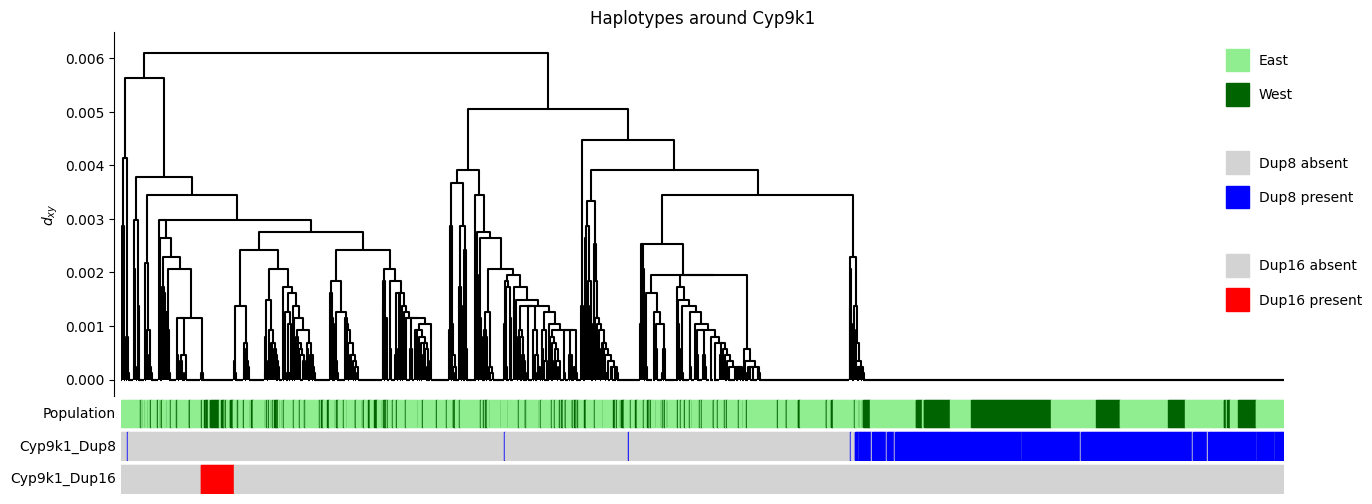

In [ ]:
# Now let's plot the haplotype clustering tree

nearest_snp_index = np.argmin(np.abs(haps_Dup.variant_position - focal_pos).values)
haptree_region_indices = range(nearest_snp_index - window_size//2, nearest_snp_index + window_size//2)
haptree_region = 'X:' + '-'.join(haps_Dup.isel(variants = haptree_region_indices).variant_position.values[[0,-1]].astype('str'))
loc_hap = hap_array_Dup[haptree_region_indices]
# loc_hap is the haplotype array for just those 500 SNPs. 

# Calculate the distance matrix 
dist = allel.pairwise_distance(loc_hap, metric = 'hamming')
# Site filter is not related to which samples are chosen, so no need to filter samples
site_filter = ag3.snp_calls(region=haptree_region, sample_sets = sample_sets)['variant_filter_pass_gamb_colu']
n_bases = np.sum(site_filter.values)
dist_dxy = dist * loc_hap.n_variants / n_bases

z = scipy.cluster.hierarchy.linkage(dist_dxy, method="complete")
r = scipy.cluster.hierarchy.dendrogram(
        z, no_labels=True, count_sort=True,
        color_threshold=0, no_plot=True,
        above_threshold_color='k')


Dup8_hap_status = np.array(['Dup8 absent', 'Dup8 present'])[Dup8_hap_proxy]

Dup16_hap_status = np.array(['Dup16 absent', 'Dup16 present'])[Dup16_hap_proxy]


draw_hap_cluster_plot_two_cnvs(z, r, loc_hap, 
                               pop_colour_scheme = pop_colours, 
                               cnv1_colour_scheme = dup_colours,
                               cnv2_colour_scheme = dup_colours,
                               labels_for_pop_colours = hap_meta_Dup['Location'], 
                               labels_for_cnv1_colours = Dup8_hap_status, 
                               labels_for_cnv2_colours = Dup16_hap_status, 
                               cnv1_name = 'Cyp9k1_Dup8',
                               cnv2_name = 'Cyp9k1_Dup16',
                               title = 'Haplotypes around Cyp9k1',
                               fn = 'Cyp9k1_Dups_haplotype_clustering.png'
)

In [ ]:
Dup8_hap_proxy

array([0, 1, 1, ..., 0, 1, 1], dtype=int8)

In [ ]:
discordant_read_calls_allCyp9k1=(
    ag3.cnv_discordant_read_calls(contig='X',sample_sets= sample_sets)
       .set_index(samples="sample_id", variants="variant_id")
       .sel(samples = meta.index)
       #.sel(variants = 'Cyp9k1')
)

# Convert genotypes to a pandas DataFrame
df_cyp9k1 = discordant_read_calls_allCyp9k1["call_genotype"].to_pandas()

# Remove CNVs that are absent in all samples
df_cyp9k1 = df_cyp9k1.loc[(df_cyp9k1 != 0).any(axis=1)]
df_cyp9k1

# Get the total number of samples carrying each CNV
df_cyp9k1.sum(axis=1)

    

variants
Cyp9k1_Dup0     621
Cyp9k1_Dup5      11
Cyp9k1_Dup8     570
Cyp9k1_Dup16     54
Cyp9k1_Dup19      5
dtype: int64

In [ ]:
df_cyp9k1

samples,VBS50275-6645STDY11194051,VBS50276-6645STDY11194052,VBS50283-6645STDY11194053,VBS50286-6645STDY11194055,VBS50287-6645STDY11194056,VBS50288-6645STDY11194057,VBS50289-6645STDY11194058,VBS50291-6645STDY11194059,VBS50293-6645STDY11194060,VBS50294-6645STDY11194061,...,VBS67010-6645STDY13057654,VBS67012-6645STDY13057656,VBS67013-6645STDY13057657,VBS67014-6645STDY13057658,VBS67020-6645STDY13057664,VBS67021-6645STDY13057665,VBS67022-6645STDY13057666,VBS67024-6645STDY13057668,VBS67025-6645STDY13057669,VBS67026-6645STDY13057670
variants,,,,,,,,,,,,,,,,,,,,,
Cyp9k1_Dup0,1,1,0,1,1,1,0,0,0,0,...,1,1,1,1,1,1,0,1,1,1
Cyp9k1_Dup5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Cyp9k1_Dup8,1,1,0,1,1,1,0,0,0,0,...,1,1,1,1,1,1,0,1,1,1
Cyp9k1_Dup16,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Cyp9k1_Dup19,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Given that we don't have a SNP with perfect correlation, let's try just looking at copy number of the SNP on the genotype

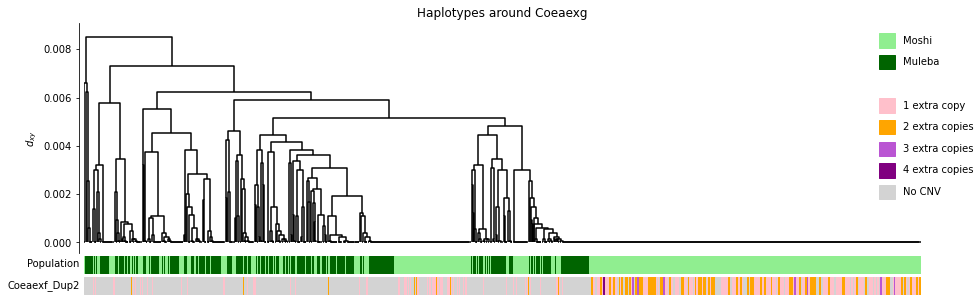

In [ ]:
#Dup_status = np.array(['Dup absent', 'Dup present'])[discordant_read_calls['Coeaexf_Dup2'].astype('int')]
Dup_status = np.array(['No CNV', '1 extra copy', '2 extra copies', '3 extra copies', '4 extra copies'])[np.repeat(Dup_copy_number, 2)]

draw_hap_cluster_plot(z, r, loc_hap, 
                      pop_colour_scheme = pop_colours, 
                      cnv_colour_scheme = dup_colours,
                      labels_for_pop_colours = hap_meta['location'], 
                      labels_for_cnv_colours = Dup_status, 
                      cnv_name = 'Coeaexf_Dup2',
                      title = 'Haplotypes around Coeaexg',
                      fn = 'Coeaexf_haplotype_clustering_copy_number.png'
)

So there are still members of the swept cluster that don't have the haplotype, which suggests that the CNV appeared on the existing swept cluster. 

In [ ]:
# Can we find correlated SNPs that aren't among the phased haplotypes
snps = (
    ag3.snp_calls(region = region, 
                   sample_sets = sample_sets)
    .set_index(samples = 'sample_id')
    .sel(samples = discordant_read_calls.index)
)
snps

<xarray.Dataset>
Dimensions:                             (variants: 499961, alleles: 4,
                                         samples: 467, ploidy: 2)
Coordinates:
    variant_position                    (variants) int32 dask.array<chunksize=(182189,), meta=np.ndarray>
    variant_contig                      (variants) uint8 dask.array<chunksize=(182189,), meta=np.ndarray>
  * samples                             (samples) <U36 'VBS54893-6781STDY1215...
Dimensions without coordinates: variants, alleles, ploidy
Data variables:
    variant_allele                      (variants, alleles) |S1 dask.array<chunksize=(182189, 1), meta=np.ndarray>
    variant_filter_pass_gamb_colu_arab  (variants) bool dask.array<chunksize=(294925,), meta=np.ndarray>
    variant_filter_pass_gamb_colu       (variants) bool dask.array<chunksize=(294925,), meta=np.ndarray>
    variant_filter_pass_arab            (variants) bool dask.array<chunksize=(294925,), meta=np.ndarray>
    call_genotype                       (variants, samples, ploidy) int8 dask.array<chunksize=(294925, 50, 2), meta=np.ndarray>
    call_GQ                             (variants, samples) int8 dask.array<chunksize=(294925, 50), meta=np.ndarray>
    call_MQ                             (variants, samples) float32 dask.array<chunksize=(294925, 50), meta=np.ndarray>
    call_AD                             (variants, samples, alleles) int16 dask.array<chunksize=(294925, 50, 4), meta=np.ndarray>
    call_genotype_mask                  (variants, samples, ploidy) bool dask.array<chunksize=(294925, 50, 2), meta=np.ndarray>
Attributes:
    contigs:  ('2R', '2L', '3R', '3L', 'X')

In [ ]:
# That's a lot bigger than the haplotypes. 
# Let's start by removing SNPs that are non-segregating or singletons in this dataset
gen_array = allel.GenotypeArray(snps.call_genotype)
gen_ac = gen_array.count_alleles()
gen_ac

<AlleleCountsArray shape=(499961, 4) dtype=int32>
0 0 0 0
0 0 0 0
0 0 0 0
...
934   0   0   0
934   0   0   0
926   0   0   8

In [ ]:
gen_is_segregating = gen_ac.is_segregating()
gen_segregating_ac = gen_ac[gen_is_segregating, :]
gen_segregating_ac

<AlleleCountsArray shape=(69977, 4) dtype=int32>
196   2   0   0
147   0   0  53
  0   0   5 267
...
662 272   0   0
931   3   0   0
926   0   0   8

In [ ]:
min_maf = 50
keep_snp = np.max(gen_segregating_ac, 1) <= (gen_array.shape[1]*2 - min_maf)
filtered_snps = snps.sel(variants = gen_is_segregating).sel(variants = keep_snp)
filtered_snps

<xarray.Dataset>
Dimensions:                             (variants: 24611, alleles: 4,
                                         samples: 467, ploidy: 2)
Coordinates:
    variant_position                    (variants) int32 dask.array<chunksize=(12793,), meta=np.ndarray>
    variant_contig                      (variants) uint8 dask.array<chunksize=(12793,), meta=np.ndarray>
  * samples                             (samples) <U36 'VBS54893-6781STDY1215...
Dimensions without coordinates: variants, alleles, ploidy
Data variables:
    variant_allele                      (variants, alleles) |S1 dask.array<chunksize=(12793, 1), meta=np.ndarray>
    variant_filter_pass_gamb_colu_arab  (variants) bool dask.array<chunksize=(15814,), meta=np.ndarray>
    variant_filter_pass_gamb_colu       (variants) bool dask.array<chunksize=(15814,), meta=np.ndarray>
    variant_filter_pass_arab            (variants) bool dask.array<chunksize=(15814,), meta=np.ndarray>
    call_genotype                       (variants, samples, ploidy) int8 dask.array<chunksize=(15814, 50, 2), meta=np.ndarray>
    call_GQ                             (variants, samples) int8 dask.array<chunksize=(15814, 50), meta=np.ndarray>
    call_MQ                             (variants, samples) float32 dask.array<chunksize=(15814, 50), meta=np.ndarray>
    call_AD                             (variants, samples, alleles) int16 dask.array<chunksize=(15814, 50, 4), meta=np.ndarray>
    call_genotype_mask                  (variants, samples, ploidy) bool dask.array<chunksize=(15814, 50, 2), meta=np.ndarray>
Attributes:
    contigs:  ('2R', '2L', '3R', '3L', 'X')

In [ ]:
# We're going to need a separate test for every allele, since you can't represent a genotype
# with more than two alleles as a single number.
def all_alleles_spearman(gen, thresh_allele_count = 100):
    output = [0]*4
    for i in range(4):
        allele_gen = gen == i
        if np.sum(allele_gen) < thresh_allele_count:
            p = np.nan
        else:
            p = spearmanr(np.any(allele_gen, 1).astype('int'), Dup_calls)[0]
        output[i] = p
    return(np.array(output))


In [ ]:
all_genotypes = filtered_snps.call_genotype.values


In [ ]:
gen_SNP_cor = np.array([all_alleles_spearman(all_genotypes[i, :, :]) for i in range(all_genotypes.shape[0])])
gen_SNP_cor = np.nanmax(np.abs(gen_SNP_cor), 1)
print(f'The maximum correlation coefficient with the Dup is {np.nanmax(gen_SNP_cor)}')

/home/eric/.local/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4881: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


The maximum correlation coefficient with the Dup is 0.8749092753237256


/tmp/ipykernel_560703/891186749.py:2: RuntimeWarning: All-NaN slice encountered
  gen_SNP_cor = np.nanmax(np.abs(gen_SNP_cor), 1)


That's not much better than when looking at phased haplotypes. 